In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import sys
# from lifelines import KaplanMeierFitter
# from lifelines.statistics import logrank_test

In [3]:
pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)
# print(pkg_path)
data_path=pkg_path+'/results/'
FNN_file_name='model_results_summary_for_Linear_Model.csv'
RF_file_name='model_results_summary_for_Random_Forest.csv'

FNN_model_stats=pd.read_csv(data_path+FNN_file_name)
FNN_model_stats.sort_values(by='r2_avg', ascending=False, inplace=True)
FNN_model_stats.head()


,file_name,mse_avg,mse_std,r2_avg,r2_std,mse,r2,best_model_filename,best_r2
14,Radiomic_Features_CaPTk_automaticsegm_DSC_ap-r...,149921.679688,30233.591665,0.039820,0.120156,"[154401.390625, 123462.6484375, 172005.6875, 1...","[-0.12214720249176025, 0.22789400815963745, -0...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.227894
56,Radiomic_Features_CaPTk_automaticsegm_DTI_AD_E...,140960.879688,25973.182887,0.038408,0.050871,"[190049.40625, 128643.0234375, 113290.9375, 13...","[0.040293335914611816, 0.11447888612747192, -0...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.114479
62,Radiomic_Features_CaPTk_automaticsegm_DTI_RD_E...,147095.131250,26939.871112,-0.002515,0.046418,"[194792.28125, 144749.171875, 113208.671875, 1...","[0.01634281873703003, 0.0036113858222961426, -...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.070592
10,Radiomic_Features_CaPTk_automaticsegm_DTI_FA_E...,148152.312500,24272.660815,-0.012804,0.052102,"[188987.75, 152532.703125, 115096.515625, 1352...","[0.04565441608428955, -0.049967050552368164, -...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.055916
64,Radiomic_Features_CaPTk_automaticsegm_T1GD_ED.csv,120117.559375,10404.959585,-0.014342,0.073781,"[131896.5, 122111.6796875, 118696.234375, 1265...","[0.04537367820739746, -0.075897216796875, 0.04...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.047873


In [4]:
RF_model_stats=pd.read_csv(data_path+RF_file_name)
RF_model_stats.sort_values(by='r2_avg', ascending=False, inplace=True)
RF_model_stats.head()

,file_name,mse_avg,mse_std,r2_avg,r2_std,mse,r2,best_r2
34,Radiomic_Features_CaPTk_segm_DSC_PH_ED.csv,147856.481629,17043.907538,0.011845,0.054270,"[139720.8788547119, 165968.04800537459, 126360...","[-0.032262199669816694, -0.056542293268244004,...",0.078367
52,Radiomic_Features_CaPTk_automaticsegm_T1GD_NC.csv,138588.395710,15913.914210,-0.004002,0.088821,"[153954.56654627254, 137771.63516131547, 13113...","[0.11760700127601664, -0.1305638123053705, 0.0...",0.117607
28,Radiomic_Features_CaPTk_automaticsegm_DTI_TR_E...,147524.150941,18682.754668,-0.017514,0.098257,"[183054.9718947884, 141836.37198315898, 130080...","[0.0756136424035827, 0.023661928602996096, -0....",0.075614
7,Radiomic_Features_CaPTk_automaticsegm_DSC_PSR_...,154276.063015,27053.540863,-0.022332,0.067827,"[160346.3170516418, 120200.7501017659, 157527....","[0.008905348022634763, -0.012648680177592464, ...",0.083321
56,Radiomic_Features_CaPTk_automaticsegm_DTI_AD_E...,150747.830539,28218.344228,-0.026005,0.028711,"[201039.8782937233, 153412.31435906494, 114797...","[-0.015206082107255492, -0.05602167508673195, ...",0.021182


In [ ]:
print('The highest performing simple NN models are:')
for model in FNN_model_stats['file_name'].iloc[0:10].tolist():
    print(model)

The highest performing simple NN models are:
Radiomic_Features_CaPTk_segm_DSC_PH_ED.csv
Radiomic_Features_CaPTk_automaticsegm_T1GD_NC.csv
Radiomic_Features_CaPTk_automaticsegm_DTI_TR_ET.csv
Radiomic_Features_CaPTk_automaticsegm_DSC_PSR_ED.csv
Radiomic_Features_CaPTk_automaticsegm_DTI_AD_ET.csv
Radiomic_Features_CaPTk_automaticsegm_FLAIR_NC.csv
Radiomic_Features_CaPTk_automaticsegm_T2_ED.csv
Radiomic_Features_CaPTk_automaticsegm_DSC_ap-rCBV_NC.csv
Radiomic_Features_CaPTk_automaticsegm_DTI_RD_ET.csv
Radiomic_Features_CaPTk_segm_T2_ED.csv


It seems that DTI (Diffusion Tensor Imaging), ET (enhancing tumor) models perform the best on the simple NN model. Perhaps it is also worth mentioning that ED also places highly.

DTI is a medical imaging technique that measures the diffusion of water molecules in biological tissues, providing information about tissue microstructure and integrity. It is often used to study brain white matter and can help identify areas of damage or disease.

The top performing model seems to use the dynamic susceptibility contrast (DSC) modality,  automatically-extracted proxy to relative Cerebral Blood Volume (ap-rCBV), and edema (ED). DSC and NC also performs highly which might suggest that the model is picking up on the tumor's vascularity and edema and may be complementary to the information provided by the DTI modality.

Key definitions:
|   Acronym   |                            Image Type                           |
|:-----------:|:---------------------------------------------------------------:|
|      T1     |                      Native T1-weighted MR Image                      |
|     T1Gd    |     Post-contrast T1-weighted MR Image (also known as T1c, T1-CE)     |
| DSC-ap-rCBV |    automatically-extracted proxy to relative Cerebral Blood Volume    |
|  PERFUSION  | Dynamic Susceptibility Contrast-enhanced MR Image (also known as DSC) |
|     DTI     |                         Diffusion Tensor Image                        |
|    DTI-FA   |                      Fractional Anisotropy                      |
|    DTI-AX   |                        Axial Diffusivity                        |
|   DTI-RAD   |                        Radial Diffusivity                       |
|    DTI-TR   |                              Trace                              |
| DSC-ap-rCBV | automatically-extracted proxy to relative Cerebral Blood Volume |
|    DSC-PH   |                           Peak Height                           |
|   DSC-PSR   |                    Percentage Signal Recovery                   |

|       ED       |              Edema              |
|       NC      |             Necrosis            |
|       ET       |         Enhancing Tumor         |

From: https://github.com/CBICA/CaPTk/blob/master/2_GettingStarted.txt

This is in agreement with the top models for MGMT methylation prediction, which found the highest performing models to be DTI and DTI+DSC. 
Paper:
https://iopscience.iop.org/article/10.1088/2057-1976/ad6573

/home/ee577/miniconda3/envs/ee577/lib/python3.10/site-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


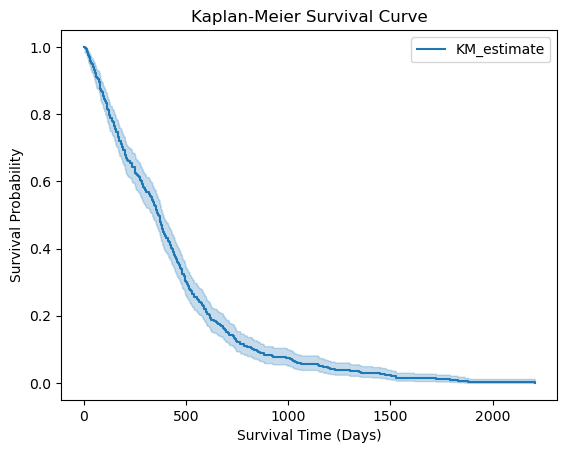

In [ ]:
path_4_clinical_info = 'Datasets/UPENN_GBM'

# Checks if survival days is available for patients
data_availability = pd.read_csv(os.path.join(pkg_path, path_4_clinical_info,'UPENN-GBM_data_availability.csv'))
data_availability = data_availability[data_availability['Overall Survival'] != 'not available']
patient_ids = data_availability['ID']

# Load clinical info
clinical_info = pd.read_csv(os.path.join(pkg_path,path_4_clinical_info, 'UPENN-GBM_clinical_info_v2.1.csv'))
clinical_info = clinical_info[clinical_info['ID'].isin(patient_ids)]
clinical_info = clinical_info.set_index('ID')

survival_days = clinical_info['Survival_from_surgery_days_UPDATED']

kmf_actual = KaplanMeierFitter()
kmf_actual.fit(durations=survival_days)

kmf_actual.plot()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Survival Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

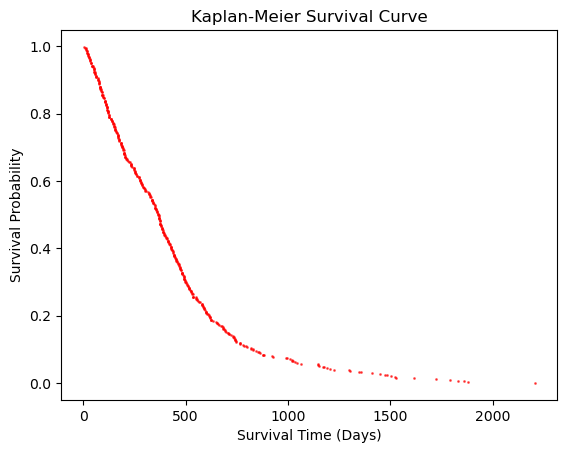

In [ ]:
survival_days = pd.to_numeric(survival_days)
event_survival_probs = [kmf_actual.predict(t) for t in survival_days]

plt.scatter(survival_days, event_survival_probs, color='red', marker='o',s=1, alpha=0.6)
plt.title("Kaplan-Meier Survival Curve: Actual survival")
plt.xlabel("Survival Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

### How to tell if your model is doing anything
Graphical:
If the machine learning model predicts that a patient will survive for 100 days and it is a continuous prediction and the Kaplan-Meier curve to predicts survival probability at 100 days for the same patient to be 80% survival probability at 100 days, you could compare this to the actual survival time, graphically.

Statistical:
Or you can use a Log-Rank test to compare the survival curves between groups (e.g., patients with predicted survival less than 100 days vs. more than 100 days). This can give you a p-value to assess whether the model's prediction significantly differentiates between survival outcomes.


In [ ]:
# Graphical:
data= # Dataframe with ML model predictions
data['Event_Observed_Predicted'] = (data['Survival_Days'] <= data['Predicted_Survival']).astype(int)

kmf_predicted = KaplanMeierFitter()
kmf_predicted.fit(durations=data['Predicted_Survival'])

# Plot Kaplan-Meier curves
plt.figure(figsize=(10, 6))
kmf_actual.plot(label="Actual Survival")
kmf_predicted.plot(label="Predicted Survival", linestyle='--')

# Show plot
plt.title("Kaplan-Meier Survival Curves")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [ ]:
# Statistical:
actual_survival_data= # Clinical data
predicted_survival_data= # Dataframe with ML model predictions

results = logrank_test(actual_survival_data['Survival_Days'], predicted_survival_data['Predicted_Survival_Days'])
print("Log-Rank Test p-value:", results.p_value)

In [ ]:
# To do: 
# 1. Train a better models from the top modalities and extract the features from the best models
# 2. Compare models to Kaplin Meyer estimates-> Statistical significance/ p-values